In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import DataLoader, Subset, ConcatDataset
from sklearn.model_selection import train_test_split
from torchvision import datasets, transforms



train_dataset = datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
)

test_dataset = datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True,
)

print(train_dataset.data.shape)
print(test_dataset.data.shape)

torch.Size([60000, 28, 28])
torch.Size([10000, 28, 28])


In [2]:
# Tên các lớp
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

# Lấy label dưới dạng Python list / NumPy (không thao tác với tensor)
train_labels = np.array(train_dataset.targets.tolist())
test_labels = np.array(test_dataset.targets.tolist())

# Ghép tất cả label lại và đếm
all_labels = np.concatenate([train_labels, test_labels])
counts = np.bincount(all_labels, minlength=len(class_names))

print("\nSố lượng mẫu theo từng nhãn:")
for i, name in enumerate(class_names):
    print(f"{i} - {name}: {counts[i]} mẫu")


Số lượng mẫu theo từng nhãn:
0 - T-shirt/top: 7000 mẫu
1 - Trouser: 7000 mẫu
2 - Pullover: 7000 mẫu
3 - Dress: 7000 mẫu
4 - Coat: 7000 mẫu
5 - Sandal: 7000 mẫu
6 - Shirt: 7000 mẫu
7 - Sneaker: 7000 mẫu
8 - Bag: 7000 mẫu
9 - Ankle boot: 7000 mẫu


In [3]:
full_dataset = ConcatDataset([train_dataset, test_dataset])

all_labels = np.concatenate([
    train_dataset.targets.numpy(),
    test_dataset.targets.numpy()
])

indices = np.arange(len(full_dataset))

# 60% train
train_idx, temp_idx = train_test_split(
    indices,
    test_size=0.4,
    stratify=all_labels,
    random_state=42
)

# 20% val + 20% test
temp_labels = all_labels[temp_idx]

val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.5,
    stratify=temp_labels,
    random_state=42
)

train_dataset = Subset(full_dataset, train_idx)
val_dataset = Subset(full_dataset, val_idx)
test_dataset = Subset(full_dataset, test_idx)

print(f"Train: {len(train_dataset)}")
print(f"Val:   {len(val_dataset)}")
print(f"Test:  {len(test_dataset)}")

for name, idx in [
    ("Train", train_idx),
    ("Val", val_idx),
    ("Test", test_idx)
]:
    labels = all_labels[idx]
    counts = np.bincount(labels)

    print(f"\n{name}")
    for i in range(10):
        print(f"{class_names[i]:12s}: {counts[i]}")

Train: 42000
Val:   14000
Test:  14000

Train
T-shirt/top : 4200
Trouser     : 4200
Pullover    : 4200
Dress       : 4200
Coat        : 4200
Sandal      : 4200
Shirt       : 4200
Sneaker     : 4200
Bag         : 4200
Ankle boot  : 4200

Val
T-shirt/top : 1400
Trouser     : 1400
Pullover    : 1400
Dress       : 1400
Coat        : 1400
Sandal      : 1400
Shirt       : 1400
Sneaker     : 1400
Bag         : 1400
Ankle boot  : 1400

Test
T-shirt/top : 1400
Trouser     : 1400
Pullover    : 1400
Dress       : 1400
Coat        : 1400
Sandal      : 1400
Shirt       : 1400
Sneaker     : 1400
Bag         : 1400
Ankle boot  : 1400


In [4]:
import torch
from torchvision import transforms

# Chuyển ảnh sang tensor khi load
to_tensor = transforms.ToTensor()

# Wrapper để áp transform lên Subset mà không sửa dataset gốc
class TransformedSubset(torch.utils.data.Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform
    def __len__(self):
        return len(self.subset)
    def __getitem__(self, idx):
        img, label = self.subset[idx]   # trả về PIL image, label
        if self.transform:
            img = self.transform(img)   # trở thành tensor
        return img, label

wrapped_train = TransformedSubset(train_dataset, transform=to_tensor)

# Dataloader: giảm batch_size nếu bị thiếu RAM. Trên Windows để an toàn xài num_workers=0.
loader = DataLoader(wrapped_train, batch_size=256, shuffle=False, num_workers=0)

sum_ = torch.zeros(1)
sum_sq = torch.zeros(1)
n_pixels = 0

for batch_imgs, _ in loader:
    batch_imgs = batch_imgs.float()              # B x C x H x W
    B, C, H, W = batch_imgs.shape
    n_pixels += B * H * W
    # cộng theo kênh: kết quả shape (C,)
    sum_ += batch_imgs.sum(dim=[0,2,3])
    sum_sq += (batch_imgs ** 2).sum(dim=[0,2,3])

mean = (sum_ / n_pixels).tolist()    # danh sách length = C (ở đây C=1)
std = ( (sum_sq / n_pixels - (sum_/n_pixels)**2).sqrt() ).tolist()

print("mean:", mean)
print("std: ", std)

mean: [0.28584545850753784]
std:  [0.3527945876121521]


In [5]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

In [6]:
# Tạo transformed subsets
train_ds = TransformedSubset(train_dataset, transform=train_transform)
val_ds   = TransformedSubset(val_dataset, transform=test_transform)
test_ds  = TransformedSubset(test_dataset, transform=test_transform)

# DataLoaders
batch_size = 128
num_workers = 0
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=num_workers, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)

In [7]:
import timm

model = timm.create_model(
    'deit_tiny_patch16_224',
    pretrained=True,
    num_classes=10
)

D:\clothes_recognition\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [8]:
print(model)

VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 192, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((192,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=192, out_features=576, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (norm): Identity()
        (proj): Linear(in_features=192, out_features=192, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((192,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=192, out_features=768, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=False)


In [9]:
for name, module in model.named_modules():
    print(name, "->", module)

 -> VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 192, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((192,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=192, out_features=576, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (norm): Identity()
        (proj): Linear(in_features=192, out_features=192, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((192,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=192, out_features=768, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=Fal

In [10]:
total_params = sum(p.numel() for p in model.parameters())
print(f"{total_params:,}")

5,526,346


In [11]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)
print("Using device:", device)
model = model.to(device)

Using device: cuda


In [12]:
for param in model.parameters():
    param.requires_grad = False

for param in model.head.parameters():
    param.requires_grad = True

trainable_params = sum(
    p.numel() for p in model.parameters()
    if p.requires_grad
)

total_params = sum(
    p.numel() for p in model.parameters()
)

print(f"Trainable: {trainable_params:,}")
print(f"Total: {total_params:,}")

Trainable: 1,930
Total: 5,526,346


In [13]:
import torch.optim as optim

optimizer = optim.Adam(
    model.head.parameters(),
    lr=1e-3
)

import torch.nn as nn

criterion = nn.CrossEntropyLoss()

In [14]:
def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in dataloader:

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, predicted = outputs.max(1)

        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [15]:
@torch.no_grad()
def evaluate(model, dataloader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in dataloader:

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = model(images)

        loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)

        _, predicted = outputs.max(1)

        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [16]:
import copy

best_model_weights = None
num_epochs = 50
best_val_loss = float("inf")
best_epoch = 0
early_stop_counter = 0
patience = 9

for epoch in range(num_epochs):

    train_loss, train_acc = train_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_acc = evaluate(
        model,
        val_loader,
        criterion,
        device
    )

    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

    if val_loss < best_val_loss:

        best_val_loss = val_loss
        best_epoch = epoch + 1
        early_stop_counter = 0

        best_model_weights = copy.deepcopy(
            model.state_dict()
        )

        print(
            f"Best model updated "
            f"(epoch {best_epoch})"
        )

    else:

        early_stop_counter += 1

        print(
            f"No improvement "
            f"({early_stop_counter}/{patience})"
        )

    if early_stop_counter >= patience:

        print(
            f"Early stopping at epoch {epoch+1}"
        )

        break

Epoch 1/50 | Train Loss: 0.6894 | Train Acc: 0.7837 | Val Loss: 0.4777 | Val Acc: 0.8358
Best model updated (epoch 1)
Epoch 2/50 | Train Loss: 0.4615 | Train Acc: 0.8365 | Val Loss: 0.4270 | Val Acc: 0.8475
Best model updated (epoch 2)
Epoch 3/50 | Train Loss: 0.4265 | Train Acc: 0.8480 | Val Loss: 0.4083 | Val Acc: 0.8553
Best model updated (epoch 3)
Epoch 4/50 | Train Loss: 0.4103 | Train Acc: 0.8510 | Val Loss: 0.3964 | Val Acc: 0.8577
Best model updated (epoch 4)
Epoch 5/50 | Train Loss: 0.3954 | Train Acc: 0.8588 | Val Loss: 0.3859 | Val Acc: 0.8629
Best model updated (epoch 5)
Epoch 6/50 | Train Loss: 0.3917 | Train Acc: 0.8585 | Val Loss: 0.3849 | Val Acc: 0.8622
Best model updated (epoch 6)
Epoch 7/50 | Train Loss: 0.3830 | Train Acc: 0.8609 | Val Loss: 0.3804 | Val Acc: 0.8648
Best model updated (epoch 7)
Epoch 8/50 | Train Loss: 0.3798 | Train Acc: 0.8611 | Val Loss: 0.3801 | Val Acc: 0.8623
Best model updated (epoch 8)
Epoch 9/50 | Train Loss: 0.3775 | Train Acc: 0.8640 | Va

In [17]:
model.load_state_dict(best_model_weights)

<All keys matched successfully>

In [22]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)
from sklearn.preprocessing import label_binarize


def evaluate_model(model, dataloader, device, num_classes, class_names=None):

    model.eval()

    all_labels = []
    all_preds = []
    all_probs = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)              # logits
            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)

            all_labels.append(labels.cpu())
            all_preds.append(preds.cpu())
            all_probs.append(probs.cpu())

    y_true = torch.cat(all_labels).numpy()
    y_pred = torch.cat(all_preds).numpy()
    y_prob = torch.cat(all_probs).numpy()

    # =========================
    # ACCURACY
    # =========================
    acc = accuracy_score(y_true, y_pred)

    # =========================
    # PER-CLASS METRICS
    # =========================
    precision_cls = precision_score(y_true, y_pred, average=None, zero_division=0)
    recall_cls = recall_score(y_true, y_pred, average=None, zero_division=0)
    f1_cls = f1_score(y_true, y_pred, average=None, zero_division=0)

    # =========================
    # SUMMARY METRICS
    # =========================
    precision_macro = precision_score(y_true, y_pred, average="macro", zero_division=0)
    recall_macro = recall_score(y_true, y_pred, average="macro", zero_division=0)
    f1_macro = f1_score(y_true, y_pred, average="macro", zero_division=0)

    precision_weighted = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    recall_weighted = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    f1_weighted = f1_score(y_true, y_pred, average="weighted", zero_division=0)

    # =========================
    # AUC (MULTI-CLASS OVR)
    # =========================
    y_true_bin = label_binarize(y_true, classes=list(range(num_classes)))

    auc = roc_auc_score(
        y_true_bin,
        y_prob,
        multi_class="ovr",
        average="macro"
    )

    # =========================
    # CONFUSION MATRIX
    # =========================
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names if class_names else range(num_classes),
        yticklabels=class_names if class_names else range(num_classes)
    )
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    plt.show()

    # =========================
    # PRINT RESULTS
    # =========================
    print("\n================ VALIDATION RESULT ================\n")

    print(f"Accuracy: {acc:.4f}")
    print(f"AUC     : {auc:.4f}")

    print("\n---- Macro ----")
    print(f"Precision: {precision_macro:.4f}")
    print(f"Recall   : {recall_macro:.4f}")
    print(f"F1-score : {f1_macro:.4f}")

    print("\n---- Weighted ----")
    print(f"Precision: {precision_weighted:.4f}")
    print(f"Recall   : {recall_weighted:.4f}")
    print(f"F1-score : {f1_weighted:.4f}")

    print("\n---- Per-class ----")
    if class_names is None:
        class_names = [f"class_{i}" for i in range(num_classes)]

    for i in range(num_classes):
        print(f"{class_names[i]:15s} | "
              f"P: {precision_cls[i]:.4f} | "
              f"R: {recall_cls[i]:.4f} | "
              f"F1: {f1_cls[i]:.4f}")

    return {
        "acc": acc,
        "auc": auc,
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "f1_macro": f1_macro
    }

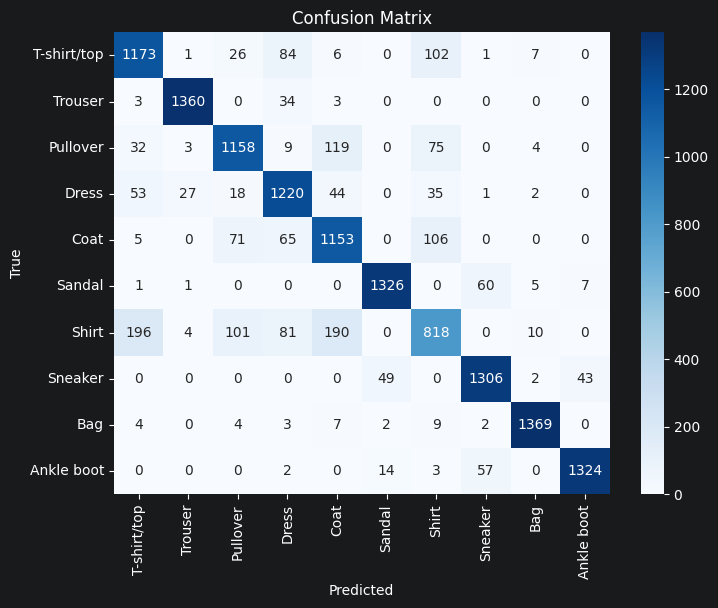


================ VALIDATION RESULT ================

Accuracy: 0.8719
AUC     : 0.9890

---- Macro ----
Precision: 0.8709
Recall   : 0.8719
F1-score : 0.8705

---- Weighted ----
Precision: 0.8709
Recall   : 0.8719
F1-score : 0.8705

---- Per-class ----
T-shirt/top     | P: 0.7996 | R: 0.8379 | F1: 0.8183
Trouser         | P: 0.9742 | R: 0.9714 | F1: 0.9728
Pullover        | P: 0.8403 | R: 0.8271 | F1: 0.8337
Dress           | P: 0.8144 | R: 0.8714 | F1: 0.8420
Coat            | P: 0.7576 | R: 0.8236 | F1: 0.7892
Sandal          | P: 0.9533 | R: 0.9471 | F1: 0.9502
Shirt           | P: 0.7125 | R: 0.5843 | F1: 0.6421
Sneaker         | P: 0.9152 | R: 0.9329 | F1: 0.9239
Bag             | P: 0.9786 | R: 0.9779 | F1: 0.9782
Ankle boot      | P: 0.9636 | R: 0.9457 | F1: 0.9546


In [23]:
metrics = evaluate_model(
    model,
    val_loader,
    device,
    num_classes=10,
    class_names=class_names
)

In [24]:
import copy

optimizer = optim.Adam(
    model.head.parameters(),
    lr=5e-5
)

best_model_weights = None
num_epochs = 10
best_val_loss = float("inf")
best_epoch = 0
early_stop_counter = 0
patience = 3

for epoch in range(num_epochs):

    train_loss, train_acc = train_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_acc = evaluate(
        model,
        val_loader,
        criterion,
        device
    )

    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

    if val_loss < best_val_loss:

        best_val_loss = val_loss
        best_epoch = epoch + 1
        early_stop_counter = 0

        best_model_weights = copy.deepcopy(
            model.state_dict()
        )

        print(
            f"Best model updated "
            f"(epoch {best_epoch})"
        )

    else:

        early_stop_counter += 1

        print(
            f"No improvement "
            f"({early_stop_counter}/{patience})"
        )

    if early_stop_counter >= patience:

        print(
            f"Early stopping at epoch {epoch+1}"
        )

        break

model.load_state_dict(best_model_weights)

Epoch 1/10 | Train Loss: 0.3440 | Train Acc: 0.8751 | Val Loss: 0.3588 | Val Acc: 0.8708
Best model updated (epoch 1)
Epoch 2/10 | Train Loss: 0.3447 | Train Acc: 0.8740 | Val Loss: 0.3574 | Val Acc: 0.8716
Best model updated (epoch 2)
Epoch 3/10 | Train Loss: 0.3427 | Train Acc: 0.8755 | Val Loss: 0.3572 | Val Acc: 0.8713
Best model updated (epoch 3)
Epoch 4/10 | Train Loss: 0.3406 | Train Acc: 0.8762 | Val Loss: 0.3565 | Val Acc: 0.8720
Best model updated (epoch 4)
Epoch 5/10 | Train Loss: 0.3429 | Train Acc: 0.8760 | Val Loss: 0.3569 | Val Acc: 0.8713
No improvement (1/3)
Epoch 6/10 | Train Loss: 0.3423 | Train Acc: 0.8758 | Val Loss: 0.3557 | Val Acc: 0.8726
Best model updated (epoch 6)
Epoch 7/10 | Train Loss: 0.3416 | Train Acc: 0.8756 | Val Loss: 0.3572 | Val Acc: 0.8715
No improvement (1/3)
Epoch 8/10 | Train Loss: 0.3436 | Train Acc: 0.8743 | Val Loss: 0.3567 | Val Acc: 0.8711
No improvement (2/3)
Epoch 9/10 | Train Loss: 0.3427 | Train Acc: 0.8760 | Val Loss: 0.3564 | Val Acc

<All keys matched successfully>

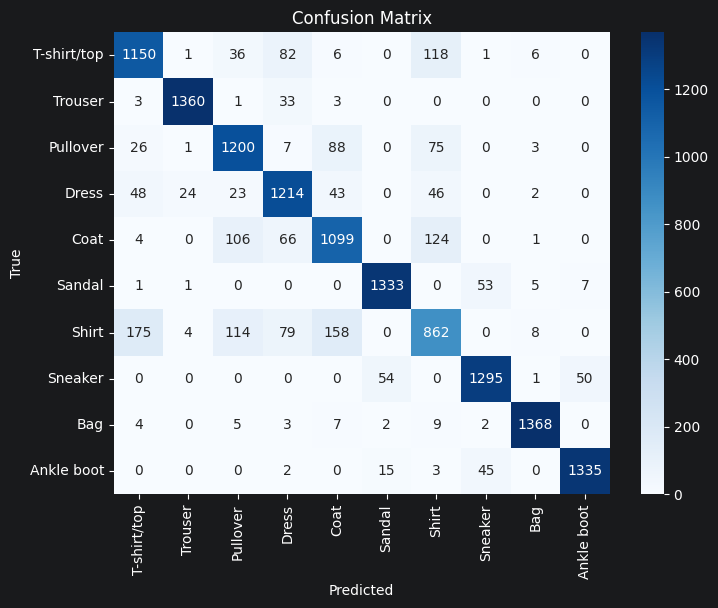


================ VALIDATION RESULT ================

Accuracy: 0.8726
AUC     : 0.9890

---- Macro ----
Precision: 0.8715
Recall   : 0.8726
F1-score : 0.8716

---- Weighted ----
Precision: 0.8715
Recall   : 0.8726
F1-score : 0.8716

---- Per-class ----
T-shirt/top     | P: 0.8150 | R: 0.8214 | F1: 0.8182
Trouser         | P: 0.9777 | R: 0.9714 | F1: 0.9746
Pullover        | P: 0.8081 | R: 0.8571 | F1: 0.8319
Dress           | P: 0.8170 | R: 0.8671 | F1: 0.8413
Coat            | P: 0.7828 | R: 0.7850 | F1: 0.7839
Sandal          | P: 0.9494 | R: 0.9521 | F1: 0.9508
Shirt           | P: 0.6968 | R: 0.6157 | F1: 0.6538
Sneaker         | P: 0.9277 | R: 0.9250 | F1: 0.9263
Bag             | P: 0.9813 | R: 0.9771 | F1: 0.9792
Ankle boot      | P: 0.9591 | R: 0.9536 | F1: 0.9563


In [25]:
metrics = evaluate_model(
    model,
    val_loader,
    device,
    num_classes=10,
    class_names=class_names
)

In [26]:
import copy

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

best_model_weights = None
num_epochs = 10
best_val_loss = float("inf")
best_epoch = 0
early_stop_counter = 0
patience = 3

for epoch in range(num_epochs):

    train_loss, train_acc = train_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_acc = evaluate(
        model,
        val_loader,
        criterion,
        device
    )

    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

    if val_loss < best_val_loss:

        best_val_loss = val_loss
        best_epoch = epoch + 1
        early_stop_counter = 0

        best_model_weights = copy.deepcopy(
            model.state_dict()
        )

        print(
            f"Best model updated "
            f"(epoch {best_epoch})"
        )

    else:

        early_stop_counter += 1

        print(
            f"No improvement "
            f"({early_stop_counter}/{patience})"
        )

    if early_stop_counter >= patience:

        print(
            f"Early stopping at epoch {epoch+1}"
        )

        break

model.load_state_dict(best_model_weights)

Epoch 1/10 | Train Loss: 1.3032 | Train Acc: 0.8771 | Val Loss: 1.3146 | Val Acc: 0.8709
Best model updated (epoch 1)
Epoch 2/10 | Train Loss: 1.2247 | Train Acc: 0.8747 | Val Loss: 1.2442 | Val Acc: 0.8694
Best model updated (epoch 2)
Epoch 3/10 | Train Loss: 1.1637 | Train Acc: 0.8735 | Val Loss: 1.1873 | Val Acc: 0.8666
Best model updated (epoch 3)
Epoch 4/10 | Train Loss: 1.1123 | Train Acc: 0.8702 | Val Loss: 1.1399 | Val Acc: 0.8652
Best model updated (epoch 4)
Epoch 5/10 | Train Loss: 1.0699 | Train Acc: 0.8710 | Val Loss: 1.1007 | Val Acc: 0.8623
Best model updated (epoch 5)
Epoch 6/10 | Train Loss: 1.0345 | Train Acc: 0.8720 | Val Loss: 1.0695 | Val Acc: 0.8607
Best model updated (epoch 6)
Epoch 7/10 | Train Loss: 1.0111 | Train Acc: 0.8691 | Val Loss: 1.0421 | Val Acc: 0.8601
Best model updated (epoch 7)
Epoch 8/10 | Train Loss: 0.9876 | Train Acc: 0.8684 | Val Loss: 1.0202 | Val Acc: 0.8596
Best model updated (epoch 8)
Epoch 9/10 | Train Loss: 0.9693 | Train Acc: 0.8667 | Va

<All keys matched successfully>

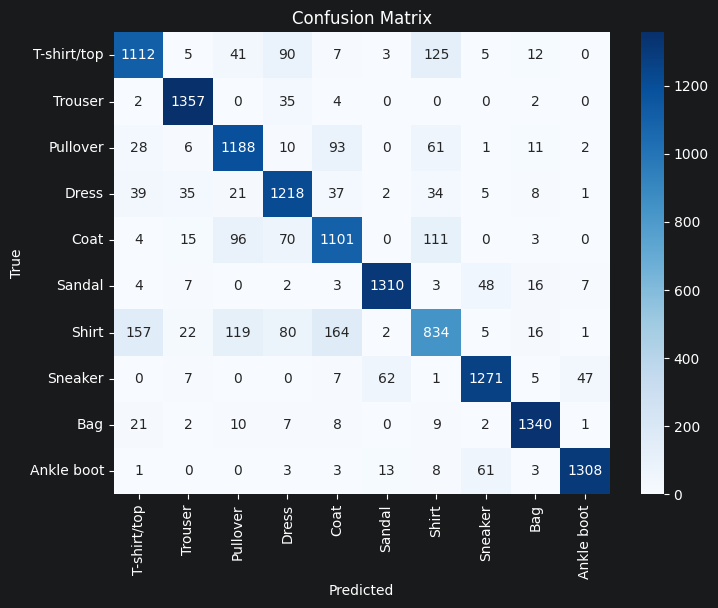


================ VALIDATION RESULT ================

Accuracy: 0.8599
AUC     : 0.9865

---- Macro ----
Precision: 0.8582
Recall   : 0.8599
F1-score : 0.8584

---- Weighted ----
Precision: 0.8582
Recall   : 0.8599
F1-score : 0.8584

---- Per-class ----
T-shirt/top     | P: 0.8129 | R: 0.7943 | F1: 0.8035
Trouser         | P: 0.9320 | R: 0.9693 | F1: 0.9503
Pullover        | P: 0.8054 | R: 0.8486 | F1: 0.8264
Dress           | P: 0.8040 | R: 0.8700 | F1: 0.8357
Coat            | P: 0.7715 | R: 0.7864 | F1: 0.7789
Sandal          | P: 0.9411 | R: 0.9357 | F1: 0.9384
Shirt           | P: 0.7032 | R: 0.5957 | F1: 0.6450
Sneaker         | P: 0.9092 | R: 0.9079 | F1: 0.9085
Bag             | P: 0.9463 | R: 0.9571 | F1: 0.9517
Ankle boot      | P: 0.9568 | R: 0.9343 | F1: 0.9454


In [27]:
metrics = evaluate_model(
    model,
    val_loader,
    device,
    num_classes=10,
    class_names=class_names
)

In [28]:
more_augment_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),

    transforms.RandomHorizontalFlip(p=0.5), # Lật trái phải (rất thực tế với quần áo)

    # Thay vì dùng cả Affine + Crop + Rotation, ta gộp chung vào một lệnh Affine nhẹ nhàng:
    transforms.RandomAffine(
        degrees=10,           # Chỉ xoay nhẹ tối đa 10 độ
        translate=(0.05, 0.05), # Dịch chuyển nhẹ 5% để mô hình không bị học vẹt vị trí
        scale=(0.9, 1.1)      # Co giãn nhẹ từ 90% đến 110%
    ),

    # Giữ lại một chút tăng cường độ tương phản (giúp phân biệt nếp gấp, cúc áo)
    transforms.RandomAutocontrast(p=0.2),


    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

train_ds_augmented = TransformedSubset(train_dataset, transform=more_augment_transform)

train_loader_augmented = DataLoader(
    train_ds_augmented,
    batch_size=128,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

In [29]:
import copy



best_model_weights = None
num_epochs = 10
best_val_loss = float("inf")
best_epoch = 0
early_stop_counter = 0
patience = 3

for epoch in range(num_epochs):

    train_loss, train_acc = train_epoch(
        model,
        train_loader_augmented,
        criterion,
        optimizer,
        device
    )

    val_loss, val_acc = evaluate(
        model,
        val_loader,
        criterion,
        device
    )

    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

    if val_loss < best_val_loss:

        best_val_loss = val_loss
        best_epoch = epoch + 1
        early_stop_counter = 0

        best_model_weights = copy.deepcopy(
            model.state_dict()
        )

        print(
            f"Best model updated "
            f"(epoch {best_epoch})"
        )

    else:

        early_stop_counter += 1

        print(
            f"No improvement "
            f"({early_stop_counter}/{patience})"
        )

    if early_stop_counter >= patience:

        print(
            f"Early stopping at epoch {epoch+1}"
        )

        break

model.load_state_dict(best_model_weights)

Epoch 1/10 | Train Loss: 0.9611 | Train Acc: 0.8533 | Val Loss: 0.9775 | Val Acc: 0.8594
Best model updated (epoch 1)
Epoch 2/10 | Train Loss: 0.9481 | Train Acc: 0.8551 | Val Loss: 0.9665 | Val Acc: 0.8595
Best model updated (epoch 2)
Epoch 3/10 | Train Loss: 0.9441 | Train Acc: 0.8558 | Val Loss: 0.9595 | Val Acc: 0.8594
Best model updated (epoch 3)
Epoch 4/10 | Train Loss: 0.9333 | Train Acc: 0.8567 | Val Loss: 0.9512 | Val Acc: 0.8603
Best model updated (epoch 4)
Epoch 5/10 | Train Loss: 0.9288 | Train Acc: 0.8570 | Val Loss: 0.9448 | Val Acc: 0.8594
Best model updated (epoch 5)
Epoch 6/10 | Train Loss: 0.9213 | Train Acc: 0.8585 | Val Loss: 0.9384 | Val Acc: 0.8605
Best model updated (epoch 6)
Epoch 7/10 | Train Loss: 0.9167 | Train Acc: 0.8587 | Val Loss: 0.9330 | Val Acc: 0.8613
Best model updated (epoch 7)
Epoch 8/10 | Train Loss: 0.9137 | Train Acc: 0.8577 | Val Loss: 0.9267 | Val Acc: 0.8619
Best model updated (epoch 8)
Epoch 9/10 | Train Loss: 0.9101 | Train Acc: 0.8589 | Va

<All keys matched successfully>

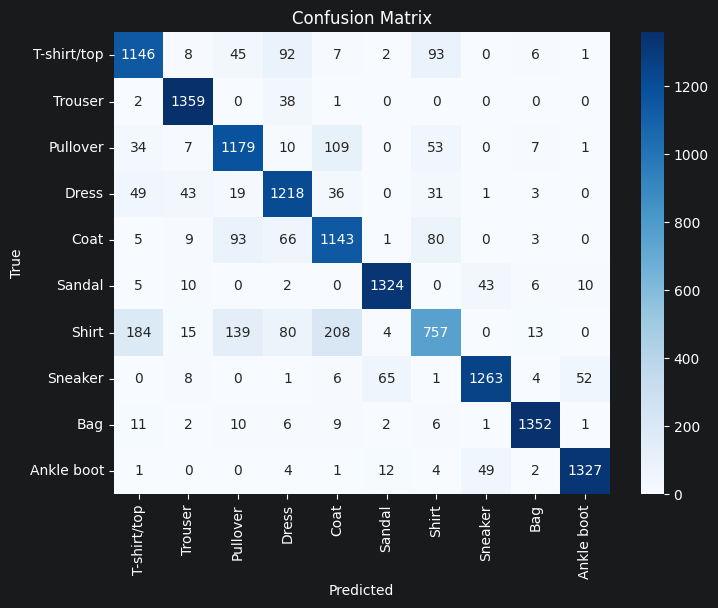


================ VALIDATION RESULT ================

Accuracy: 0.8620
AUC     : 0.9866

---- Macro ----
Precision: 0.8607
Recall   : 0.8620
F1-score : 0.8594

---- Weighted ----
Precision: 0.8607
Recall   : 0.8620
F1-score : 0.8594

---- Per-class ----
T-shirt/top     | P: 0.7975 | R: 0.8186 | F1: 0.8079
Trouser         | P: 0.9302 | R: 0.9707 | F1: 0.9500
Pullover        | P: 0.7939 | R: 0.8421 | F1: 0.8173
Dress           | P: 0.8029 | R: 0.8700 | F1: 0.8351
Coat            | P: 0.7520 | R: 0.8164 | F1: 0.7829
Sandal          | P: 0.9390 | R: 0.9457 | F1: 0.9423
Shirt           | P: 0.7385 | R: 0.5407 | F1: 0.6243
Sneaker         | P: 0.9307 | R: 0.9021 | F1: 0.9162
Bag             | P: 0.9685 | R: 0.9657 | F1: 0.9671
Ankle boot      | P: 0.9533 | R: 0.9479 | F1: 0.9506


In [30]:
metrics = evaluate_model(
    model,
    val_loader,
    device,
    num_classes=10,
    class_names=class_names
)

In [32]:
strong_augmentation = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),   # giữ như cũ

    # 1. Lật ngang – rất thực tế với quần áo (tay trái/phải)
    transforms.RandomHorizontalFlip(p=0.5),

    # 2. Xoay mạnh hơn một chút – giúp phân biệt dress vs coat (viền cổ)
    transforms.RandomRotation(degrees=15, fill=0),  # fill=0 cho vùng đen

    # 3. Cắt xén + co giãn tỷ lệ – bắt mô hình học shape thay vì vị trí tuyệt đối
    transforms.RandomResizedCrop(size=(224, 224), scale=(0.8, 1.0), ratio=(0.9, 1.1)),

    # 4. Biến dạng affine mạnh hơn (xoay, dịch, tỉ lệ)
    transforms.RandomAffine(
        degrees=10,            # vẫn giữ nhẹ để tránh phá hủy cấu trúc
        translate=(0.1, 0.1),  # dịch 10% (tăng từ 5%)
        scale=(0.85, 1.15),    # co giãn ±15%
        shear=5                # thêm shear nhẹ (5 độ) – mô phỏng góc chụp nghiêng
    ),

    # 5. Biến đổi màu sắc & tương phản – giúp phân biệt pullover (len) vs coat (vải bóng)
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1, hue=0.05),

    # 6. Chuyển sang xám một cách ngẫu nhiên (bỏ màu) – tăng robustness
    transforms.RandomGrayscale(p=0.1),

    # 7. Làm mờ Gaussian – mô phỏng ảnh thiếu nét, ép mô hình học shape tổng thể
    transforms.RandomApply([transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.5))], p=0.3),

    # 8. Điều chỉnh độ tương phản tự động (thỉnh thoảng)
    transforms.RandomAutocontrast(p=0.2),

    # 9. Chuẩn hóa về tensor
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])


train_ds_strong_augmented = TransformedSubset(train_dataset, transform=strong_augmentation)

train_loader_strong_augmented = DataLoader(
    train_ds_strong_augmented,
    batch_size=128,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

In [35]:
import copy

best_model_weights = None
num_epochs = 50
best_val_loss = float("inf")
best_epoch = 0
early_stop_counter = 0
patience = 9

for epoch in range(num_epochs):

    train_loss, train_acc = train_epoch(
        model,
        train_loader_strong_augmented,
        criterion,
        optimizer,
        device
    )

    val_loss, val_acc = evaluate(
        model,
        val_loader,
        criterion,
        device
    )

    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

    if val_loss < best_val_loss:

        best_val_loss = val_loss
        best_epoch = epoch + 1
        early_stop_counter = 0

        best_model_weights = copy.deepcopy(
            model.state_dict()
        )

        print(
            f"Best model updated "
            f"(epoch {best_epoch})"
        )

    else:

        early_stop_counter += 1

        print(
            f"No improvement "
            f"({early_stop_counter}/{patience})"
        )

    if early_stop_counter >= patience:

        print(
            f"Early stopping at epoch {epoch+1}"
        )

        break

model.load_state_dict(best_model_weights)

Epoch 1/50 | Train Loss: 1.0195 | Train Acc: 0.8024 | Val Loss: 0.9322 | Val Acc: 0.8563
Best model updated (epoch 1)
Epoch 2/50 | Train Loss: 1.0081 | Train Acc: 0.8091 | Val Loss: 0.9354 | Val Acc: 0.8555
No improvement (1/9)
Epoch 3/50 | Train Loss: 1.0001 | Train Acc: 0.8120 | Val Loss: 0.9385 | Val Acc: 0.8527
No improvement (2/9)
Epoch 4/50 | Train Loss: 0.9961 | Train Acc: 0.8111 | Val Loss: 0.9366 | Val Acc: 0.8531
No improvement (3/9)
Epoch 5/50 | Train Loss: 0.9898 | Train Acc: 0.8175 | Val Loss: 0.9380 | Val Acc: 0.8510
No improvement (4/9)
Epoch 6/50 | Train Loss: 0.9893 | Train Acc: 0.8174 | Val Loss: 0.9358 | Val Acc: 0.8510
No improvement (5/9)
Epoch 7/50 | Train Loss: 0.9824 | Train Acc: 0.8175 | Val Loss: 0.9344 | Val Acc: 0.8516
No improvement (6/9)
Epoch 8/50 | Train Loss: 0.9824 | Train Acc: 0.8190 | Val Loss: 0.9304 | Val Acc: 0.8535
Best model updated (epoch 8)
Epoch 9/50 | Train Loss: 0.9766 | Train Acc: 0.8186 | Val Loss: 0.9309 | Val Acc: 0.8528
No improvement 

<All keys matched successfully>

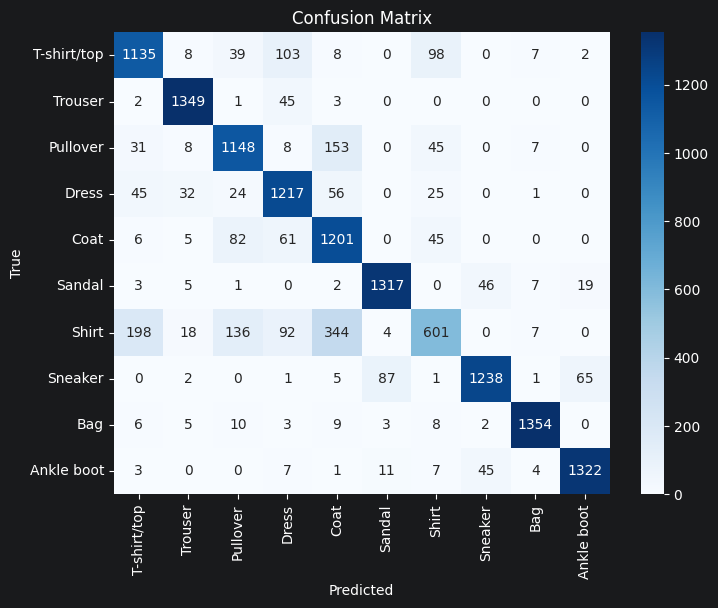


================ VALIDATION RESULT ================

Accuracy: 0.8487
AUC     : 0.9850

---- Macro ----
Precision: 0.8494
Recall   : 0.8487
F1-score : 0.8439

---- Weighted ----
Precision: 0.8494
Recall   : 0.8487
F1-score : 0.8439

---- Per-class ----
T-shirt/top     | P: 0.7943 | R: 0.8107 | F1: 0.8024
Trouser         | P: 0.9420 | R: 0.9636 | F1: 0.9527
Pullover        | P: 0.7967 | R: 0.8200 | F1: 0.8082
Dress           | P: 0.7918 | R: 0.8693 | F1: 0.8287
Coat            | P: 0.6740 | R: 0.8579 | F1: 0.7549
Sandal          | P: 0.9262 | R: 0.9407 | F1: 0.9334
Shirt           | P: 0.7241 | R: 0.4293 | F1: 0.5390
Sneaker         | P: 0.9301 | R: 0.8843 | F1: 0.9066
Bag             | P: 0.9755 | R: 0.9671 | F1: 0.9713
Ankle boot      | P: 0.9389 | R: 0.9443 | F1: 0.9416


In [36]:
metrics = evaluate_model(
    model,
    val_loader,
    device,
    num_classes=10,
    class_names=class_names
)

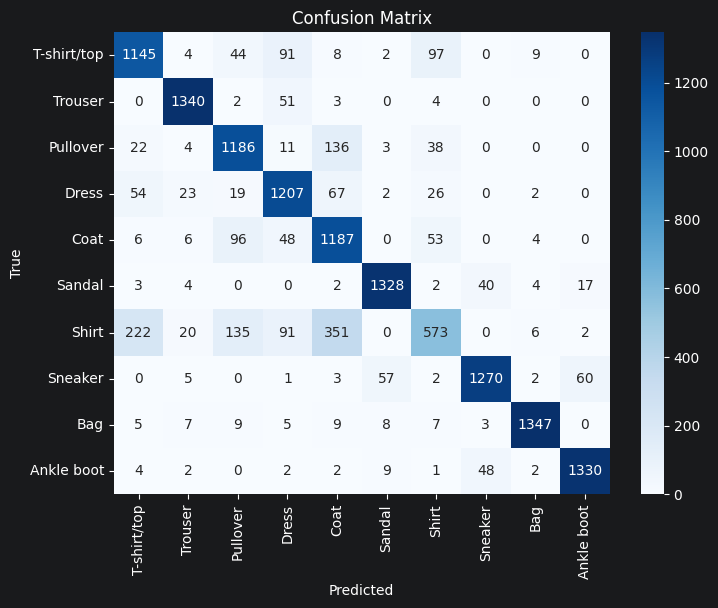


================ VALIDATION RESULT ================

Accuracy: 0.8509
AUC     : 0.9845

---- Macro ----
Precision: 0.8511
Recall   : 0.8509
F1-score : 0.8456

---- Weighted ----
Precision: 0.8511
Recall   : 0.8509
F1-score : 0.8456

---- Per-class ----
T-shirt/top     | P: 0.7837 | R: 0.8179 | F1: 0.8004
Trouser         | P: 0.9470 | R: 0.9571 | F1: 0.9520
Pullover        | P: 0.7954 | R: 0.8471 | F1: 0.8205
Dress           | P: 0.8009 | R: 0.8621 | F1: 0.8304
Coat            | P: 0.6714 | R: 0.8479 | F1: 0.7494
Sandal          | P: 0.9425 | R: 0.9486 | F1: 0.9455
Shirt           | P: 0.7136 | R: 0.4093 | F1: 0.5202
Sneaker         | P: 0.9331 | R: 0.9071 | F1: 0.9200
Bag             | P: 0.9789 | R: 0.9621 | F1: 0.9705
Ankle boot      | P: 0.9439 | R: 0.9500 | F1: 0.9470


In [37]:
metrics = evaluate_model(
    model,
    test_loader,
    device,
    num_classes=10,
    class_names=class_names
)

In [41]:
import copy
from torch.optim.lr_scheduler import ReduceLROnPlateau

optimizer = optim.Adam(model.head.parameters(), lr=1e-3, weight_decay=1e-5)

scheduler = ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.1,
    patience=3,
)

best_model_weights = None
num_epochs = 10
best_val_loss = float("inf")
best_epoch = 0
early_stop_counter = 0

early_stop_patience = 3

for epoch in range(num_epochs):

    train_loss, train_acc = train_epoch(
        model,
        train_loader_strong_augmented,
        criterion,
        optimizer,
        device
    )

    val_loss, val_acc = evaluate(
        model,
        val_loader,
        criterion,
        device
    )

    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']
    print(f"Current Learning Rate: {current_lr}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch + 1
        early_stop_counter = 0

        best_model_weights = copy.deepcopy(
            model.state_dict()
        )
        print(f"Best model updated (epoch {best_epoch})")
    else:
        early_stop_counter += 1
        print(f"No improvement ({early_stop_counter}/{early_stop_patience})")

    if early_stop_counter >= early_stop_patience:
        print(f"Early stopping at epoch {epoch+1}")
        break


if best_model_weights is not None:
    model.load_state_dict(best_model_weights)

Epoch 1/10 | Train Loss: 0.9320 | Train Acc: 0.8310 | Val Loss: 0.9083 | Val Acc: 0.8433
Current Learning Rate: 0.001
Best model updated (epoch 1)
Epoch 2/10 | Train Loss: 0.9291 | Train Acc: 0.8292 | Val Loss: 0.8977 | Val Acc: 0.8497
Current Learning Rate: 0.001
Best model updated (epoch 2)
Epoch 3/10 | Train Loss: 0.9240 | Train Acc: 0.8319 | Val Loss: 0.9102 | Val Acc: 0.8435
Current Learning Rate: 0.001
No improvement (1/3)
Epoch 4/10 | Train Loss: 0.9239 | Train Acc: 0.8308 | Val Loss: 0.9236 | Val Acc: 0.8359
Current Learning Rate: 0.001
No improvement (2/3)
Epoch 5/10 | Train Loss: 0.9222 | Train Acc: 0.8321 | Val Loss: 0.9238 | Val Acc: 0.8339
Current Learning Rate: 0.001
No improvement (3/3)
Early stopping at epoch 5
